<a href="https://colab.research.google.com/github/nehaj2026/undergrad_ml_assignments/blob/main/NJ_genomics_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
! git clone https://github.com/nehaj2026/scratchpad

Cloning into 'scratchpad'...
remote: Enumerating objects: 36, done.
remote: Counting objects: 100% (13/13), done.
remote: Compressing objects: 100% (7/7), done.
remote: Total 36 (delta 9), reused 6 (delta 6), pack-reused 23 (from 1)
Receiving objects: 100% (36/36), 64.98 KiB | 3.61 MiB/s, done.
Resolving deltas: 100% (11/11), done.


In [3]:
! git clone https://github.com/ds4e/undergrad_ml_assignments

Cloning into 'undergrad_ml_assignments'...
remote: Enumerating objects: 110, done.
remote: Counting objects: 100% (48/48), done.
remote: Compressing objects: 100% (30/30), done.
remote: Total 110 (delta 37), reused 18 (delta 18), pack-reused 62 (from 1)
Receiving objects: 100% (110/110), 11.76 MiB | 20.65 MiB/s, done.
Resolving deltas: 100% (46/46), done.


In [2]:
import urllib.request
import os
import zipfile
import os

def download_data(force=False):
    """Download and extract course data from Zenodo."""

    zip_path = 'data.zip'
    data_dir = './data'

    if not os.path.exists(zip_path) or force:
        print("Downloading course data...")
        urllib.request.urlretrieve(
            'https://zenodo.org/records/18235955/files/data.zip?download=1',
            zip_path
        )
        print("Download complete")

    if not os.path.exists(data_dir) or force:
        print("Extracting data files...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(data_dir)
        print("Data extracted")

    return data_dir


if __name__ == "__main__":
    download_data()



Download complete
Extracting data files...
Data extracted


Genomics
Leukemia is a cancer of blood-generating tissues. Over 475,000 Americans have Leukemia or are in remission from it. It accounts for 3.3% of all new cancer cases and 3.8% of cancer deaths, with an estimated 66,890 new cases and 23,540 deaths in the U.S. in 2025.

There are two major leukemia families: Acute Lymphoblastic Leukemia (ALLB and ALLT, or ALL), which is cancer of immature lymphoid cells, and Acute Myeloid Leukemia (AML), which is cancer of cancer of immature myeloid cells.

Golub et al. (Science, 1999) popularized a dataset including about 7000 genes from 72 patients. The goal is to use genomics data to predict which patients are at risk of ALL versus AML, because the distinction is critical for timely and effective treatment.

1. Load the golub.csv dataset. Relabel all instances of ALLB and ALLT as 0, and all instances of ALL as 1. This is the target variable.

2. Use Linear Regression of the target variable on all of the genes provided. What is your mean squared error? Make a kernel density plot of your residuals, and a scatter plot comparing predicted and actual outcomes.

3. Use cross validation to compute the mean squared error of the linear model. Discuss your results from the perspective of the bias variance trade-off.

4. Use the cross validated LASSO to select a set of highly predictive genes. Which set of genes is selected? How many genes are discarded from the model? Make a scatterplot of your predictions versus the actual values.

5. Make a plot that shows the cross validated MSE as
 varies. For what values of
 is the LASSO underfitting? Overfitting? What is the optimal penality hyperparameter that minimizes expected MSE?

6. Explain why linear regression performs perfectly on the training set, but the LASSO provides better predictions overall.

7. Why do regularization methods lend themselves to scenarios like precision health?

8. What are the risks of applying methods like the Lasso to precision health questions, where interventions will then be taken to optimize patient health?

In [4]:
import pandas as pd
import numpy as np

In [5]:
#Question 1: Load golub.csv dataset and relabel all instances of ALLB and ALLT as 0 and all instances of all as 1

df = pd.read_csv('/content/undergrad_ml_assignments/data/golub.csv')
mapper = {'allB' : 0, 'allT' : 0, 'aml' : 1}
df['y'] = df['cancer'].map(mapper)

In [6]:
genes = df.drop(['Samples', 'BM.PB', 'Gender', 'Source', 'tissue.mf', 'cancer', 'y'], axis = 1)
genes

,AFFX-BioB-5_at,AFFX-BioB-M_at,AFFX-BioB-3_at,AFFX-BioC-5_at,AFFX-BioC-3_at,AFFX-BioDn-5_at,AFFX-BioDn-3_at,AFFX-CreX-5_at,AFFX-CreX-3_at,AFFX-BioB-5_st,...,U48730_at,U58516_at,U73738_at,X06956_at,X16699_at,X83863_at,Z17240_at,L49218_f_at,M71243_f_at,Z78285_f_at
0,-1363.276427,-1058.585495,-541.469194,74.349803,-1110.082554,-1545.661845,-2037.029616,-1255.990888,-335.480958,-938.425691,...,-35.081447,1565.618803,-485.680714,-170.261227,-919.114293,1675.050053,389.769289,-526.449219,-268.963924,-779.643092
1,-796.285053,-1167.103365,7.538493,83.544731,-1116.432539,-1731.392100,249.376523,-1636.960108,-149.080421,-222.783440,...,-404.737767,622.498054,-1275.354673,214.828233,-750.220666,-441.589276,9.841713,-671.911209,-671.911209,-644.272577
2,-679.139168,-1069.832308,-690.301829,-112.075981,-1199.319178,-1286.387935,-605.465604,-1043.041921,-728.254877,388.011238,...,193.780934,162.525483,-692.534361,517.498108,-674.674103,1265.396405,-65.192805,-714.859684,3672.066149,-822.021231
3,-1164.400197,-1109.939891,-990.127218,-238.574994,-1264.607160,-1218.860503,-1255.893511,-1009.732928,-521.768585,-926.953263,...,-256.002292,-31.625831,-621.975549,-458.594630,-630.689198,937.767618,-264.715941,-635.046022,475.944222,-794.070116
4,-1299.653758,-1401.998536,-1077.543813,-437.344560,-1386.755697,-1726.453259,-1499.988218,-1219.084464,-994.796971,-670.342247,...,-509.203660,383.591216,-905.517483,-36.675640,-1116.739685,316.087213,-210.879518,-953.423549,-291.448812,-1057.945876
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,-589.611534,-877.740714,-618.647808,-192.037937,-737.026463,-969.316655,-558.341701,-857.638678,-529.305427,547.270269,...,-236.709128,475.796364,-502.502712,-4.418936,-652.151201,0.048183,-509.203391,-609.713570,4925.046956,-627.582046
68,-1552.764727,-1288.774596,-1085.544097,-232.814069,-1177.731128,-1607.238881,-207.672152,-1383.056785,-666.512143,-536.612237,...,-415.092970,657.628835,-754.508853,102.411495,-817.363646,657.628835,-410.902650,-905.360357,-109.199643,-951.453872
69,-772.071972,-809.591203,-593.303872,-193.834414,-1511.421520,-1822.610435,-1471.695276,-1129.608171,-626.409076,-825.040298,...,-621.995048,605.104501,-575.647763,-226.939618,-750.001836,596.276447,95.284364,-758.829890,-407.914731,-772.071972
70,-1124.873709,-1026.849847,-935.360908,-135.921851,-1264.285425,-1776.187819,-922.291060,-1340.526207,-1033.384771,-471.381292,...,-96.712306,1188.489447,-887.438131,88.443879,-859.120126,1693.856917,-236.124022,-769.809496,-205.627709,-861.298435


In [8]:
# Question 2.1: Linear Regression of the target variable on all of the genes provide
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model = model.fit(genes,df['y'])

y_hat = model.predict(genes)

resid = y_hat - df['y']
resid.describe()

,y
count,7.200000e+01
mean,-5.396917e-17
std,1.125596e-15
min,-2.553513e-15
25%,-7.494005e-16
50%,0.000000e+00
75%,5.828671e-16
max,2.220446e-15


In [9]:
# Question 2.2: Mean squared error
from sklearn.metrics import mean_squared_error

mean_squared_error(df['y'], y_hat)
#The mean squared error is 1.25x10^-30, which is extremely close to zero.
# This means the model fits the training data well

1.2522824482837894e-30

<Axes: xlabel='y', ylabel='Density'>

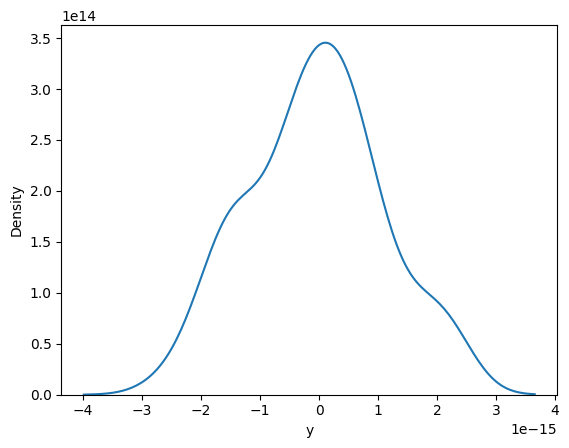

In [10]:
# Question 2.3: kde plot
import seaborn as sns
sns.kdeplot(resid)

<Axes: xlabel='y'>

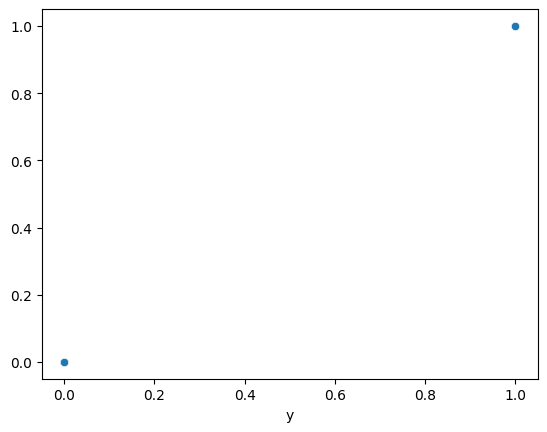

In [25]:
#Question 2.4: scatterplot
import seaborn as sns
sns.scatterplot(x=df['y'], y=y_hat)
#Model is predicting only 0 and 1, so all of the predictions are stacked in same two spots

In [24]:
#Question 3.1: Use cross validation to compute the mean squared error of the linear model
from sklearn.model_selection import KFold, cross_val_score

cv = KFold(n_splits = 10, shuffle = True, random_state = 100)
scores = -cross_val_score(model, genes, df['y'], scoring = 'neg_mean_squared_error', cv = 10)
print(np.mean(scores)) #Mean MSE is 0.068 for 10 splits
print(scores) #fold MSE

0.06780005217137444
[0.06846435 0.02128612 0.04807313 0.20310777 0.07585584 0.01899704
 0.05019037 0.03914796 0.03779801 0.11507992]


# Question 3.2: Discuss your results from the perspective of the bias variance trade-off.

For the training set, my MSE was effectively zero, for the cross validation, my MSE was 0.0678. The training MSE being so close to zero means that the model fits my training data extremely well. The cross validation MSE increasing as compared to the training validation indicates that the model is trained on the noise from the training set rather than just the generalizable patterns from the training set. This indicates that my model is overfit. In terms of the bias and variance tradeoff, the low training MSE means there is low bias and the higher MSE for cross validation indicates high variance. The tradeoff here is that by reducing one of these (ie bias or variance), the other increases. So, since the training MSE is so close to zero and bias is reduced, we see high variance.

In [30]:
#Question 4.1: Use the cross validated LASSO to select a set of highly predictive genes
from sklearn.linear_model import LinearRegression, LassoCV, lasso_path, Lasso, Ridge, RidgeCV
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import StandardScaler

model = LassoCV(cv = 10, random_state = 42, max_iter = 10000)
model = model.fit(genes, df['y'])

print("Optimal alpha:", model.alpha_)
#Best alpha is 129.75

genes_selected = genes.columns[model.coef_ != 0]
print("Genes selected:", list(genes_selected))
print("Number of genes selected:", len(genes_selected))
#30 genes selected

genes_notselected = genes.columns[model.coef_ == 0]
print("Number of genes not selected:", len(genes_notselected))
#7099 genes not selected

y_hat = model.predict(genes)
mse = mean_squared_error(df['y'], y_hat)
print("MSE:", mse)

Optimal alpha: 129.75017431132844
Genes selected: ['HG3549-HT3751_at', 'J04164_at', 'L38941_at', 'M11147_at', 'M11722_at', 'M17733_at', 'M19507_at', 'M26602_at', 'M27891_at', 'M33680_at', 'M63138_at', 'M91036_rna1_at', 'M96326_rna1_at', 'U14968_at', 'X17042_at', 'X78992_at', 'Z70759_at', 'L06797_s_at', 'D49824_s_at', 'M25079_s_at', 'X57351_s_at', 'V00594_s_at', 'U05255_s_at', 'X03689_s_at', 'M14328_s_at', 'M14483_rna1_s_at', 'Y00787_s_at', 'Z19554_s_at', 'X56681_s_at', 'HG2887-HT3031_at']
Number of genes selected: 30
Number of genes not selected: 7099
MSE: 0.01013270450745053


<Axes: xlabel='y'>

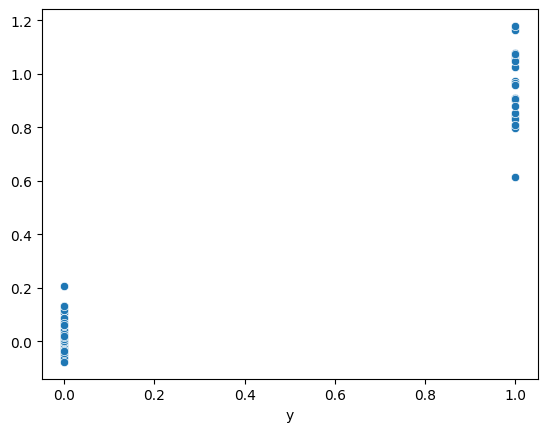

In [31]:
#Question 4.2: Make a scatterplot of your predictions versus the actual values

sns.scatterplot(x = df['y'], y = y_hat)

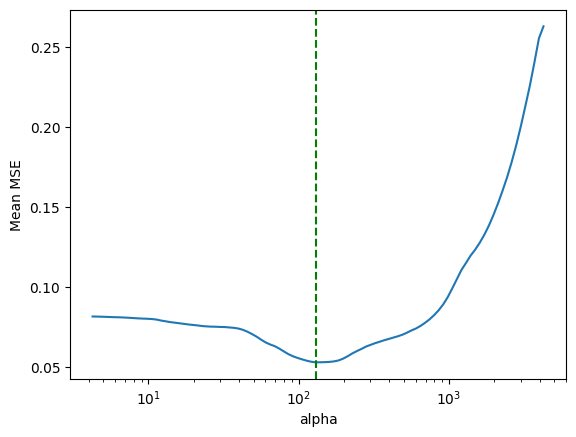

Optimal cost hyperparameter: 129.75017431132844


In [33]:
#Question 5: Make a plot that shows the cross validated MSE as varies

import matplotlib.pyplot as plt
mean_alpha_mse = model.mse_path_.mean(axis = 1)
alpha_star = model.alphas_

plt.plot(alpha_star, mean_alpha_mse)
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('Mean MSE')
plt.axvline(model.alpha_, color = 'green', linestyle = '--')
plt.show()
print(f'Optimal cost hyperparameter: {model.alpha_}')

#On the left side of the plot at low values of alpha (below 129.75), there is a weak penalty being applied and the model is overfitting the data, which has led to a higher MSE
#In the middle of the plot at an alpha of 129.75, the MSE is the lowest and the optimal spot that provides the best balance of bias and variance
#On the right side of the plot at high values of alpha (above 129.75), there is a stronger penalty being applied and the model is underfitting the data, which has led to a large increase in MSE
#The optimal cost hyperparameter/penalty is 129.75, which is where the MSE is the lowest



# Question 6: Explain why linear regression performs perfectly on the training set, but the LASSO provides better predictions overall.

Linear regression performs perfectly on the training set because it assigns parameters to every data point, including the noise in the model, which leads to overfitting and variance. It tries to minimzie the mean squared error for the whole model and by doing so it interprets noise as real patterns. This does not introduce new bias but does make variance high.

Lasso provides better predictions overall because it is adding a penalty to the loss function, which shrinks coefficients and reduces model complexity and variance. Lasso is also effectively doing feature selection by not selecting "irrelevant" coefficients, which elimates noise. By introducing this bias into the model, lasso reduces variance, which leads to better prediction for unseen data points.


# Question 7: Why do regularization methods lend themselves to scenarios like precision health?

Precision health often involves complex data that involves numerous attributes that exceed the number of observations. This sort of complexity leads to severe overfitting without regularization. Regularization is able to counteract this by performing feature selection and eliminating less relevant features. This results in preventing the model from memorizing noise in the training data and ensuring that just the generalizable patterns are learned.

# Question 8: What are the risks of applying methods like the Lasso to precision health questions, where interventions will then be taken to optimize patient health?

If the attributes are highly correlated, lasso may struggle performing feature selection, which could cause the model to miss important biological targets. Additionally, since different demographics have different health needs, lasso may arbitrarily exclude weak predictors that would be extremely relevant for patient subgroups.

Most importantly, though, lasso finds associations, not causal relationships. Interventions being taken based on the results of lasso may fail if the selected variables were not actionable targets. The composition of the training dataset may also result in unintended bias against certain groups. For example, if women were not represented in a balanced way in the training data, the model may underperform for just these affected patient subgroups.